<a href="https://colab.research.google.com/github/TorresZ314/EE344ML_homework/blob/main/344Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import time

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, KernelPCA

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Reproducibility
SEED = 42


In [2]:
# Load the dataset
DATA_PATH = "merged_dataset.csv"
df = pd.read_csv(DATA_PATH)
df = df.drop(columns = ['filename'])
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

print("\nSummary statistics:")
display(df.describe(include="all"))

print("\nMissing values per column:")
display(df.isna().sum())


Shape: (603, 64)

Columns:
['x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1', 'x_2', 'y_2', 'z_2', 'x_3', 'y_3', 'z_3', 'x_4', 'y_4', 'z_4', 'x_5', 'y_5', 'z_5', 'x_6', 'y_6', 'z_6', 'x_7', 'y_7', 'z_7', 'x_8', 'y_8', 'z_8', 'x_9', 'y_9', 'z_9', 'x_10', 'y_10', 'z_10', 'x_11', 'y_11', 'z_11', 'x_12', 'y_12', 'z_12', 'x_13', 'y_13', 'z_13', 'x_14', 'y_14', 'z_14', 'x_15', 'y_15', 'z_15', 'x_16', 'y_16', 'z_16', 'x_17', 'y_17', 'z_17', 'x_18', 'y_18', 'z_18', 'x_19', 'y_19', 'z_19', 'x_20', 'y_20', 'z_20', 'direction']


,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,z_2,x_3,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,direction
0,0.646481,0.771554,1.768660e-07,0.683290,0.711169,-0.005896,0.695399,0.647578,-0.021418,0.704892,...,0.645916,0.637718,-0.093269,0.666913,0.669813,-0.083744,0.661707,0.690624,-0.071454,Pointing_Left
1,0.162824,0.676318,-2.872858e-07,0.299672,0.617752,-0.023162,0.377253,0.549926,-0.040260,0.438199,...,0.090932,0.548127,-0.042013,0.114231,0.568613,-0.032944,0.112813,0.586741,-0.029670,Pointing_Right
2,0.863716,0.546938,2.528396e-08,0.810565,0.535083,-0.036838,0.763620,0.547465,-0.063654,0.772106,...,0.904119,0.720734,-0.104208,0.899656,0.659549,-0.097806,0.885778,0.621000,-0.086766,Pointing_Right
3,0.880592,0.755766,-5.697894e-07,0.780115,0.662776,0.026987,0.652597,0.624160,0.015813,0.538131,...,0.510331,0.795934,-0.109579,0.571014,0.808296,-0.105612,0.616264,0.785701,-0.104499,Pointing_Left
4,0.906104,0.576748,-4.809966e-07,0.816000,0.525581,0.001459,0.707359,0.512891,-0.025827,0.608692,...,0.571708,0.608426,-0.114437,0.625317,0.624875,-0.107075,0.668706,0.611069,-0.100873,Pointing_Left



Summary statistics:


,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,z_2,x_3,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,direction
count,603.000000,603.000000,6.030000e+02,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,...,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pointing_Left
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,332
mean,0.715781,0.735929,-3.487243e-07,0.706443,0.683160,0.003729,0.680230,0.634073,-0.004933,0.663679,...,0.600972,0.645125,-0.055950,0.621407,0.658073,-0.046041,0.632897,0.662758,-0.039996,NaN
std,0.225543,0.136449,3.704727e-07,0.144325,0.111320,0.025334,0.103721,0.093750,0.035670,0.115136,...,0.227899,0.137267,0.066078,0.214595,0.136413,0.068018,0.213331,0.131542,0.067879,NaN
min,0.084779,0.349867,-1.604087e-06,0.227501,0.319509,-0.074556,0.324704,0.262256,-0.098541,0.391913,...,-0.019368,0.212147,-0.216320,-0.004502,0.241364,-0.207668,-0.008087,0.261422,-0.207836,NaN
25%,0.637681,0.636364,-5.683308e-07,0.638907,0.619631,-0.014102,0.628731,0.590829,-0.029325,0.597627,...,0.459225,0.577009,-0.107140,0.516716,0.593450,-0.101291,0.551916,0.595459,-0.094182,NaN
50%,0.757556,0.764420,-3.745417e-07,0.724334,0.690265,0.005098,0.690312,0.646569,-0.003555,0.672244,...,0.663837,0.643011,-0.050791,0.684739,0.657576,-0.042030,0.707454,0.677740,-0.036421,NaN
75%,0.870812,0.826535,-5.074367e-08,0.801574,0.759805,0.021948,0.746388,0.690684,0.019525,0.747112,...,0.769731,0.737592,-0.009485,0.770573,0.748555,0.002069,0.772307,0.746388,0.009581,NaN



Missing values per column:


x_0          0
y_0          0
z_0          0
x_1          0
y_1          0
            ..
z_19         0
x_20         0
y_20         0
z_20         0
direction    0
Length: 64, dtype: int64

In [3]:
# Define categorial and numerical columns
CAT_COL = ['direction']
TARGET = 'direction'

# Dynamically select all columns that are not categorical
NUM_COLS = [col for col in df.columns if col not in CAT_COL]
if 'DATA_PATH' in locals():
    df = pd.read_csv(DATA_PATH)
    if 'filename' in df.columns:
        df = df.drop(columns=['filename'])

# Coerce numerical columns to numbers, turning errors into NaNs
df[NUM_COLS] = df[NUM_COLS].apply(pd.to_numeric, errors="coerce")

# Only drop rows where NUMERICAL columns are NaN
# We avoid dropping based on the target column to prevent losing categorical data
df = df.dropna(subset=NUM_COLS).reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("Missing values:\n", df.isna().sum())
print(df[NUM_COLS].shape)

Rows after cleaning: 603
Missing values:
 x_0          0
y_0          0
z_0          0
x_1          0
y_1          0
            ..
z_19         0
x_20         0
y_20         0
z_20         0
direction    0
Length: 64, dtype: int64
(603, 63)


In [5]:
# One hot encoding
# 1. Separate Features and Target
X_raw = df[NUM_COLS]
y_raw = df[[TARGET]]

# 2. Encode the target using OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
y_ohe = ohe.fit_transform(y_raw)
y_ohe = pd.DataFrame(y_ohe, columns=ohe.get_feature_names_out([TARGET]))

print("Target shape after OHE:", y_ohe.shape)
print("Target columns:", y_ohe.columns.tolist())

# 3. Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_ohe, test_size=0.30, random_state=SEED, stratify=y_ohe
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape,  y_test.shape)

display(y_train.head())

Target shape after OHE: (603, 2)
Target columns: ['direction_Pointing_Left', 'direction_Pointing_Right']
Train: (422, 63) (422, 2)
Test : (181, 63) (181, 2)


,direction_Pointing_Left,direction_Pointing_Right
459,0.0,1.0
453,1.0,0.0
348,0.0,1.0
84,1.0,0.0
157,0.0,1.0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

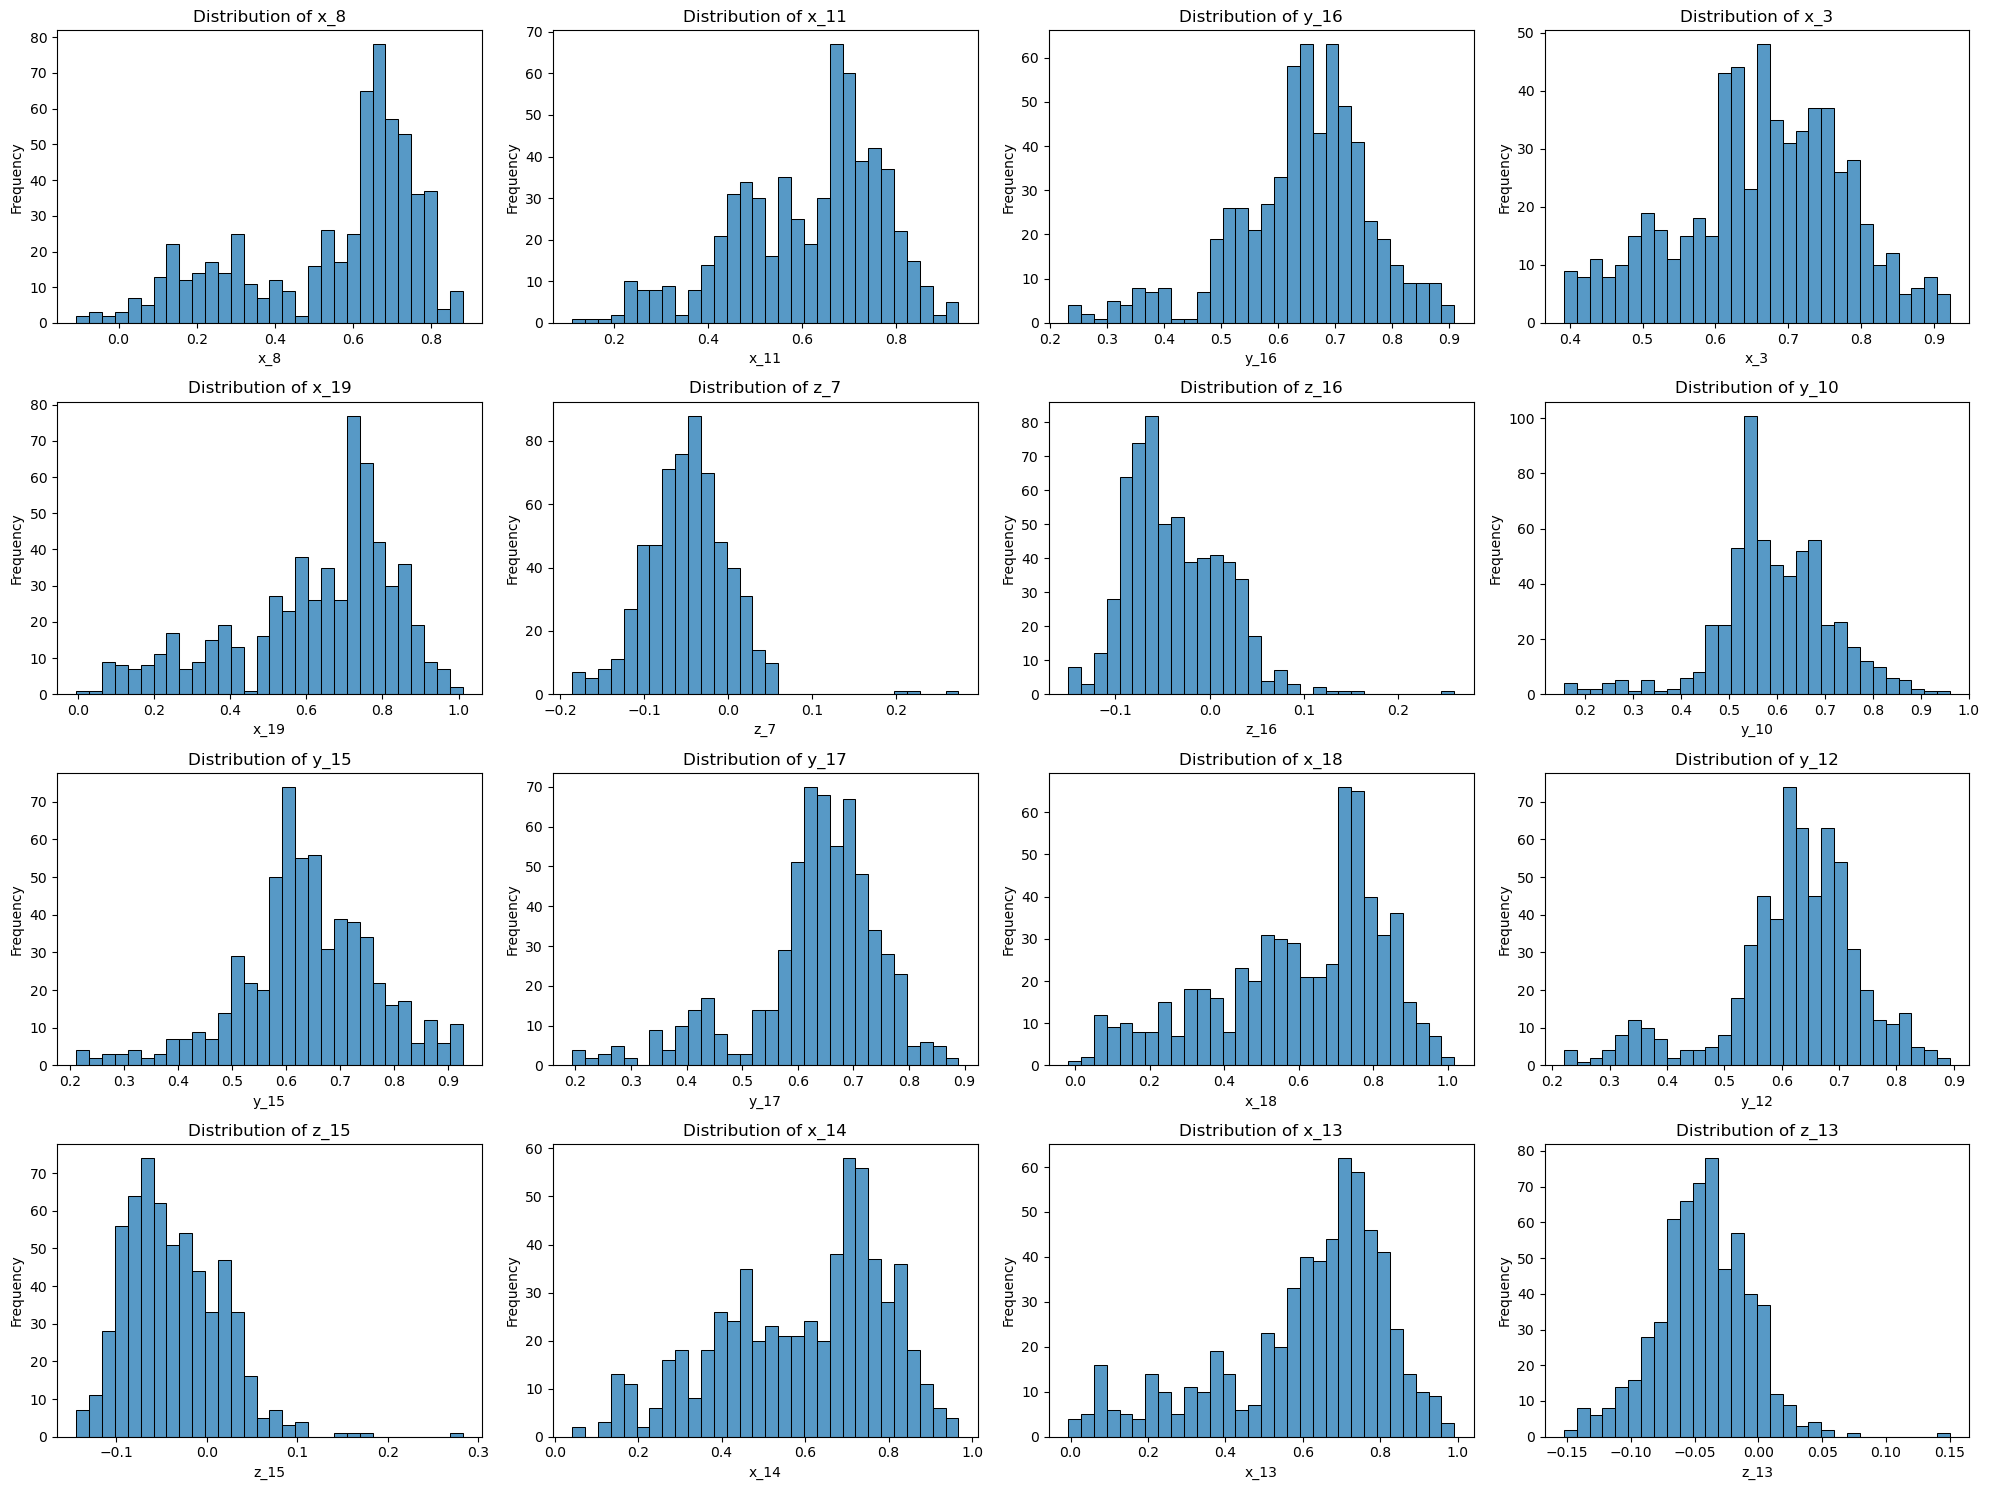

In [6]:

n_features_to_plot = 16

cols_to_plot = random.sample(NUM_COLS, n_features_to_plot)

plt.figure(figsize=(20, 15))
for i, col in enumerate(cols_to_plot):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=False, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
# Scale the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(solver = "saga", max_iter = 2000, n_jobs = -1, random_state = 42),
    "Perceptron": Perceptron(max_iter=1000, tol=1e-3, random_state=42),
    "SVM (LinearSVC)": LinearSVC(random_state=42),
    "KNN (euclidean)": KNeighborsClassifier(n_neighbors=7, metric="euclidean", n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=40, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Deep Neural Network": MLPClassifier(
      hidden_layer_sizes=(128, 64, 32), # 3 hidden layers
      activation='relu',                # Activation function
      solver='adam',                    # Optimizer
      max_iter=1000,                    # Increased max_iter for convergence
      early_stopping=True,              # Prevents overfitting
      random_state=SEED
    )
}
models.items()

dict_items([('Logistic Regression', LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42, solver='saga')), ('Perceptron', Perceptron(random_state=42)), ('SVM (LinearSVC)', LinearSVC(random_state=42)), ('KNN (euclidean)', KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=7)), ('Decision Tree', DecisionTreeClassifier(max_depth=40, random_state=42)), ('Random Forest', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)), ('Deep Neural Network', MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64, 32),
              max_iter=1000, random_state=42))])

In [29]:
# Helper Method
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def metrics(y_true, y_pred):
    """Return (accuracy, precision, recall, f1)."""
    acc = accuracy_score(y_true, y_pred)

    avg = "binary" if len(np.unique(y_true)) == 2 else "macro"

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=avg, zero_division=0
    )
    return acc, prec, rec, f1

In [34]:
results = []

# Convert OHE targets back to 1D class labels for these models
y_train_labels = np.argmax(y_train.values, axis=1)
y_test_labels = np.argmax(y_test.values, axis=1)

# Baseline Model Evaluation
for model_name, model in models.items():

      model.fit(X_train_scaled, y_train_labels)

      y_train_pred = model.predict(X_train_scaled)
      y_test_pred = model.predict(X_test_scaled)

      acc_train, prec_train, rec_train, f1_train = metrics(y_train_labels, y_train_pred)
      acc_test, prec_test, rec_test, f1_test = metrics(y_test_labels, y_test_pred)

      results.append([model_name, acc_train, prec_train, rec_train, f1_train,
                      acc_test, prec_test, rec_test, f1_test])


cols = [
    "Model",
    "Train Acc", "Train Prec", "Train Rec", "Train F1",
    "Test Acc", "Test Prec", "Test Rec", "Test F1",
]

out = pd.DataFrame(results, columns=cols).sort_values("Test F1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", 80)
print("\n=== Baseline Model Results (sorted by Test F1) ===")
print(out.to_string(index=False, formatters={
    "Train Acc": "{:.4f}".format,
    "Train Prec": "{:.4f}".format,
    "Train Rec": "{:.4f}".format,
    "Train F1": "{:.4f}".format,
    "Test Acc": "{:.4f}".format,
    "Test Prec": "{:.4f}".format,
    "Test Rec": "{:.4f}".format,
    "Test F1": "{:.4f}".format,
}))


=== Baseline Model Results (sorted by Test F1) ===
              Model Train Acc Train Prec Train Rec Train F1 Test Acc Test Prec Test Rec Test F1
      Random Forest    1.0000     1.0000    1.0000   1.0000   0.9945    1.0000   0.9877  0.9938
    SVM (LinearSVC)    1.0000     1.0000    1.0000   1.0000   0.9890    0.9877   0.9877  0.9877
Logistic Regression    0.9976     1.0000    0.9947   0.9974   0.9890    0.9877   0.9877  0.9877
    KNN (euclidean)    0.9953     0.9947    0.9947   0.9947   0.9779    0.9753   0.9753  0.9753
         Perceptron    0.9929     0.9895    0.9947   0.9921   0.9669    0.9412   0.9877  0.9639
Deep Neural Network    0.9929     0.9845    1.0000   0.9922   0.9392    0.8889   0.9877  0.9357
      Decision Tree    1.0000     1.0000    1.0000   1.0000   0.9392    0.9070   0.9630  0.9341


In [26]:
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

kpca = KernelPCA(n_components=10, kernel='rbf', random_state=42)
X_kpca = kpca.fit_transform(X_train_scaled)


In [ ]:

# predictions after PCA
results = []

for model_name, model in models.items():

      model.fit(X_pca, y_train_labels)

      y_train_pred = model.predict(X_pca)
      y_test_pred = model.predict(X_test_pca)

      acc_train, prec_train, rec_train, f1_train = metrics(y_train_labels, y_train_pred)
      acc_test, prec_test, rec_test, f1_test = metrics(y_test_labels, y_test_pred)

      results.append([model_name, acc_train, prec_train, rec_train, f1_train,
                      acc_test, prec_test, rec_test, f1_test])


cols = [
    "Model",
    "Train Acc", "Train Prec", "Train Rec", "Train F1",
    "Test Acc", "Test Prec", "Test Rec", "Test F1",
]

out = pd.DataFrame(results, columns=cols).sort_values("Test F1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", 80)
print("\n=== PCA Reduced Results (sorted by Test F1) ===")
print(out.to_string(index=False, formatters={
    "Train Acc": "{:.4f}".format,
    "Train Prec": "{:.4f}".format,
    "Train Rec": "{:.4f}".format,
    "Train F1": "{:.4f}".format,
    "Test Acc": "{:.4f}".format,
    "Test Prec": "{:.4f}".format,
    "Test Rec": "{:.4f}".format,
    "Test F1": "{:.4f}".format,
}))

NameError: name 'X_pca' is not defined

In [ ]:
# t-SNE visualization

def plot_tsne(X, labels, title, perplexity=30):
    X2 = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, (len(X) - 1) // 3)),
        init="pca",
        learning_rate="auto",
        random_state=42
    ).fit_transform(X)

    plt.figure(figsize=(8, 6))
    for lab in sorted(pd.unique(labels)):
        idx = (labels == lab)
        plt.scatter(X2[idx, 0], X2[idx, 1], label=str(lab), alpha=0.7)
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()



Plotting t-SNE on original scaled data...


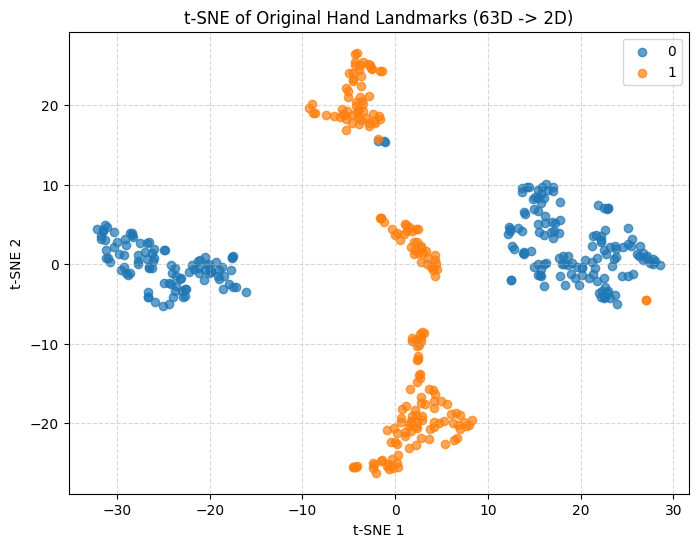

Plotting t-SNE on PCA reduced data...


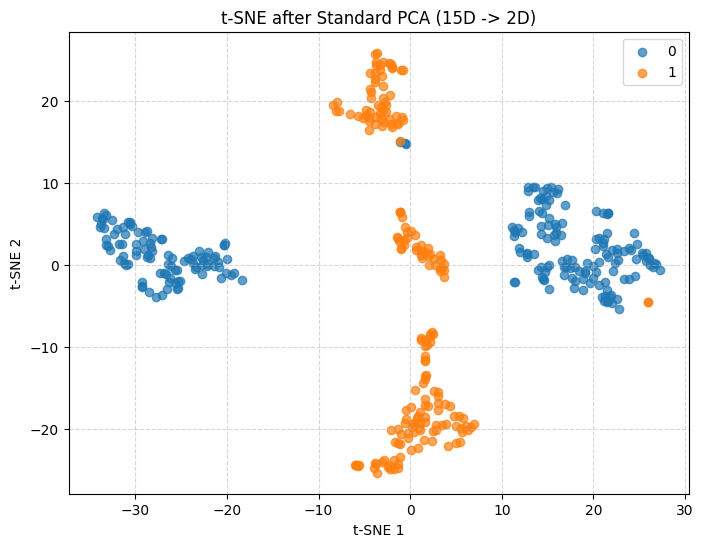

Plotting t-SNE on Kernel PCA reduced data...


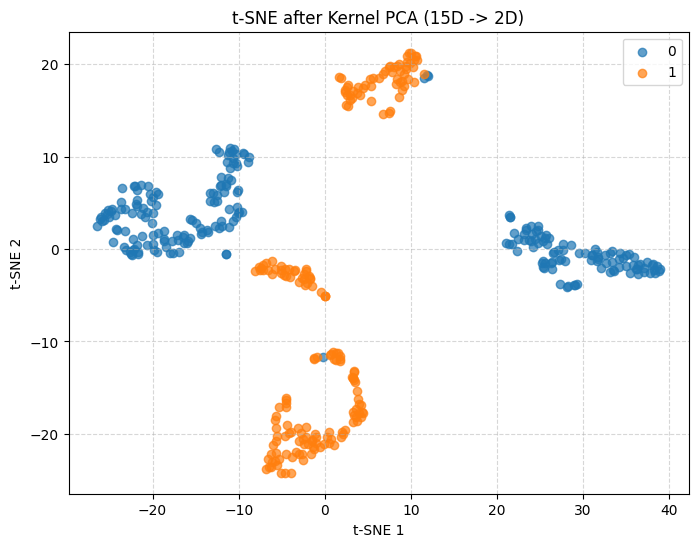

In [24]:
y_labels = np.argmax(y_train.values, axis=1)
print("Plotting t-SNE on original scaled data...")
plot_tsne(X_train_scaled, y_labels, title="t-SNE of Original Hand Landmarks (63D -> 2D)")

print("Plotting t-SNE on PCA reduced data...")
plot_tsne(X_pca, y_labels, title="t-SNE after Standard PCA (15D -> 2D)")

print("Plotting t-SNE on Kernel PCA reduced data...")
plot_tsne(X_kpca, y_labels, title="t-SNE after Kernel PCA (15D -> 2D)")

In [ ]:
# K-Means on PCA(10): Elbow, Silhouette, FMI, and cluster plots (k=2..8)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, fowlkes_mallows_score
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure this exists from earlier cells
# y_train_labels = np.argmax(y_train.values, axis=1)

K_RANGE = range(2, 9)
RANDOM_STATE = SEED if 'SEED' in globals() else 42

# 1) Keep consistency with your earlier pipeline: reduce to 10 PCs first
pca10 = PCA(n_components=10, random_state=RANDOM_STATE)
X_km = pca10.fit_transform(X_train_scaled)

rows = []
models_by_k = {}
labels_by_k = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_km)

    models_by_k[k] = km
    labels_by_k[k] = labels

    rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X_km, labels),
        'fowlkes_mallows': fowlkes_mallows_score(y_train_labels, labels),
    })

km_results = pd.DataFrame(rows)
display(km_results.round(4))

best_k_sil = int(km_results.loc[km_results['silhouette'].idxmax(), 'k'])
best_k_fmi = int(km_results.loc[km_results['fowlkes_mallows'].idxmax(), 'k'])

# 2) Metric plots
fig, axs = plt.subplots(1, 3, figsize=(18, 4.8))

# Elbow
axs[0].plot(km_results['k'], km_results['inertia'], marker='o', linewidth=2)
axs[0].set_title('Elbow Method (Inertia vs k) [PCA10]')
axs[0].set_xlabel('k')
axs[0].set_ylabel('Inertia (SSE)')
axs[0].grid(alpha=0.3)

# Silhouette
axs[1].plot(km_results['k'], km_results['silhouette'], marker='o', linewidth=2, color='tab:green')
axs[1].axvline(best_k_sil, linestyle='--', color='gray', alpha=0.8, label=f'Best k={best_k_sil}')
axs[1].set_title('Silhouette Score vs k [PCA10]')
axs[1].set_xlabel('k')
axs[1].set_ylabel('Silhouette')
axs[1].grid(alpha=0.3)
axs[1].legend(loc='best')

# FMI
axs[2].plot(km_results['k'], km_results['fowlkes_mallows'], marker='o', linewidth=2, color='tab:purple')
axs[2].axvline(best_k_fmi, linestyle='--', color='gray', alpha=0.8, label=f'Best k={best_k_fmi}')
axs[2].set_title('Fowlkes-Mallows Index vs k [PCA10]')
axs[2].set_xlabel('k')
axs[2].set_ylabel('FMI')
axs[2].grid(alpha=0.3)
axs[2].legend(loc='best')

plt.tight_layout()
plt.show()

print(f'Best k by Silhouette: {best_k_sil}')
print(f'Best k by FMI       : {best_k_fmi}')

# 3) Cluster visualization for every k=2..8
# Project PCA10 space down to 2D only for plotting
pca2_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2_viz.fit_transform(X_km)

n_k = len(K_RANGE)
n_cols = 3
n_rows = int(np.ceil(n_k / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.8 * n_rows), squeeze=False)

for idx, k in enumerate(K_RANGE):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]

    labels = labels_by_k[k]
    km = models_by_k[k]

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=16, alpha=0.85)

    centers_2d = pca2_viz.transform(km.cluster_centers_)
    ax.scatter(
        centers_2d[:, 0], centers_2d[:, 1],
        marker='X', s=220, c='black', edgecolors='white', linewidths=1.2,
        label='centroid'
    )

    sil_k = float(km_results.loc[km_results['k'] == k, 'silhouette'].values[0])
    fmi_k = float(km_results.loc[km_results['k'] == k, 'fowlkes_mallows'].values[0])

    ax.set_title(f'k={k} | sil={sil_k:.3f} | FMI={fmi_k:.3f}')
    ax.set_xlabel('PCA2-viz 1')
    ax.set_ylabel('PCA2-viz 2')
    ax.grid(alpha=0.2)
    ax.legend(loc='best')

# Hide unused panels
for j in range(n_k, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis('off')

plt.suptitle('K-Means Clusters for k=2..8 (fit on PCA10 features)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()
